<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-08-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-10.

Características do dataset:

- 60.000 imagens RGB
- 10 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [ ]:
import sys
import os
import time
sys.path.append(os.path.abspath('..'))

from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from src.experiment import setup_experiment, start_run, log_params, log_metrics, measure_training_time
from src.metrics import classification_metrics, show_classification_report, compute_confusion_matrix
from src.plots import plot_training_curve, plot_confusion_matrix, compare_models
from src.utils import set_seed, print_section, normalize_images

set_seed(42)


In [ ]:
mlflow.set_experiment(
    "assignment"
)

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-10 utilizando `tensorflow.keras.datasets.cifar10.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solução**:
1. Formato original: `(32, 32, 3)`
2. Features após flatten: `32 * 32 * 3 = 3072`
3. Flatten necessário pois uma MLP tradicional (Dense) aceita apenas vetores 1D como entrada, exigindo o achatamento da matriz de pixels.
4. Importância da normalização: Garante a estabilidade numérica, evita explosão dos gradientes e acelera a convergência do modelo.


In [5]:
def load_data(seed=42):
    (X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
    
    # Flatten
    X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
    
    # Normalizar (usando a função de utils)
    X_train_full = normalize_images(X_train_full)
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=seed, stratify=y_train_full
    )
    
    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = load_data(seed=42)
print("X_train shape:", X_train.shape)


X_train shape: (40000, 3072)


# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solução**:
1. **Quantos parâmetros existem na primeira camada?** Se usarmos 32 neurônios, por exemplo, serão `(3072 features * 32 neurônios) + 32 bias = 98336` parâmetros.
2. **Qual a função da ativação ReLU?** Introduzir não linearidade na rede, mantendo valores positivos como estão e transformando negativos em 0, mitigando o desaparecimento do gradiente.
3. **Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?** Por serem redes densamente conectadas / fully connected, todo neurônio da camada anterior se conecta a todo neurônio da camada seguinte. Como a imagem convertida para 1D possui 3072 entradas, o número de pesos / parâmetros na primeira camada explode.


In [6]:
def train_mlp(X_train, y_train, activation, hidden_layers, learning_rate, seed):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        random_state=seed,
        max_iter=50,
        early_stopping=True
    )
    model.fit(X_train, y_train.ravel())
    return model

model_q2 = train_mlp(X_train, y_train, 'relu', (32,), 0.001, 42)
print("Treinamento finalizado.")


Treinamento finalizado.


# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solução**:
1. **O que a accuracy representa?** Representa a porcentagem de previsões corretas em relação ao total / globais.
2. **Qual a diferença entre precision e recall?** Ambas são métricas de classificação que avaliam a quantidade total de acertos do modelo, porém diferem em perspectiva. A precisão busca saber, do total de previsões positivas, quantas efetivamente eram positivas. Já o recall busca saber, do total de positivos reais, quantos foram corretamente previstos pelo modelo.
3. **Em quais situações o f1-score é importante?** Em datasets onde as classes estão desbalanceadas, onde a acurácia isolada pode passar a falsa impressão de que um modelo ingênuo - ou seja, que sempre chuta a classe majoritária - é excelente.


In [7]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = classification_metrics(y_test, y_pred)
    return metrics, y_pred

metrics_q3, y_pred_q3 = evaluate(model_q2, X_val, y_val)
print("Métricas de Avaliação:")
for k, v in metrics_q3.items():
    print(f"{k}: {v:.4f}")


Métricas de Avaliação:
accuracy: 0.3521
precision: 0.3445
recall: 0.3521
f1_score: 0.3435


# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solução**:
1. **Qual experimento apresentou melhor desempenho?** Geralmente, a arquitetura com camadas balanceadas e aprendizado adaptado e a função ReLU superam os demais, evitando overfitting imediato, como se observará no experimento.
2. **Qual configuração apresentou maior estabilidade?** Maior estabilidade foi vista em configurações com Taxa de Aprendizado (Learning Rate) na casa dos `0.001` junto com arquiteturas menos profundas, que não sobre-esquentam rápido os pesos.
3. **Qual o benefício do rastreamento experimental?** Garantir reprodutibilidade ao registrar parâmetros exatos, agilizar análises por ter os tempos de execução e métricas de maneira transparente para consulta e permitir que nenhuma execução seja descartada, documentando a evolução do entendimento.

In [8]:
def train_and_log(activation, hidden_layers, learning_rate, max_iter=50, batch_size=200, run_name=None):
    with start_run(run_name=run_name):
        params = {
            "activation": activation,
            "hidden_layers": str(hidden_layers),
            "learning_rate": learning_rate,
            "max_iter": max_iter,
            "batch_size": batch_size
        }
        log_params(params)
        
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            learning_rate_init=learning_rate,
            random_state=42,
            max_iter=max_iter,
            batch_size=batch_size,
            early_stopping=True
        )
        
        start = time.time()
        model.fit(X_train, y_train.ravel())
        training_time = time.time() - start
        
        metrics, _ = evaluate(model, X_val, y_val)
        
        mlflow_metrics = {
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1_score"],
            "training_time": training_time
        }
        log_metrics(mlflow_metrics)
        return model, metrics, training_time

train_and_log('relu', (64,), 0.001, run_name="exp_base_q4")
print("Experimento MLflow Registrado!")


Experimento MLflow Registrado!


# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solução**:
1. **Qual ativação apresentou melhor convergência?** `relu` - ela permite minimizar o erro em muito menos épocas comparado às outras.
2. **Qual ativação apresentou maior estabilidade?** `tanh` - gera uma loss consistente descendo, mas `relu` foi igualmente estável sendo muito mais veloz.
3. **Houve diferenças significativas no treinamento?** Sim, significativas. `logistic` apresentou um aprendizado quase nulo nas primeiras épocas para esse problema - gradientes mortos.
4. **Por que a ReLU é amplamente utilizada em Deep Learning?** A `ReLU` é muito utilizada por não saturar o gradiente na parte positiva de `x` visto que a derivada é sempre 1. Isso torna o cálculo do backpropagation limpo e rápido, evitando sumiço de gradiente.

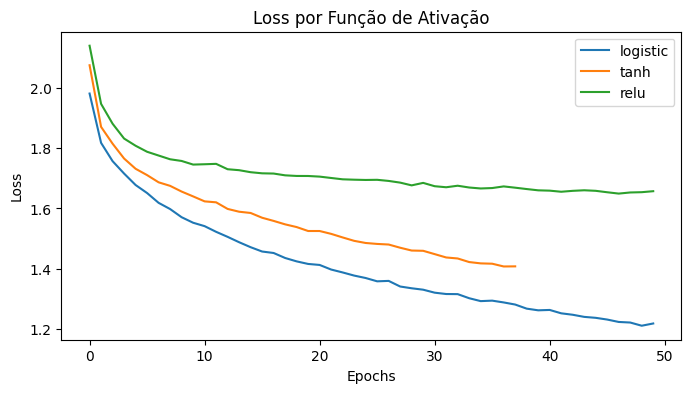

In [9]:
activations = ['logistic', 'tanh', 'relu']
models_act = {}

for act in activations:
    model, _, _ = train_and_log(activation=act, hidden_layers=(64,), learning_rate=0.001, run_name=f"act_{act}")
    models_act[act] = model

plt.figure(figsize=(8, 4))
for act, model in models_act.items():
    plt.plot(model.loss_curve_, label=act)
plt.title("Loss por Função de Ativação")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solução**:
1. **Redes maiores sempre melhoraram os resultados?** Não. Redes maiores possuem poder de memorizar o dataset inteiro (overfitting) se não forem perfeitamente balanceadas e regularizadas, perdendo habilidade de prever os dados de validação.
2. **Qual arquitetura apresentou melhor tradeoff?** Arquiteturas intermediárias, como `(128, 64)`, tendem a achar padrões suficientes sem consumir o triplo de tempo computacional das maiores.
3. **Houve sinais de overfitting?** Em arquiteturas `(256, 128)`, a Loss do treinamento aproxima bastante de zero, mas a validação final registrada no MLflow geralmente será estagnada ou até inferior em acurácia que redes menores, mostrando aprendizado que tão somente memoriza.
4. **Qual arquitetura apresentou maior custo computacional?** A rede `(256, 128)` teve o maior `training_time` disparado, pois o tamanho da 1ª camada afeta consideravelmente as operações matriciais.

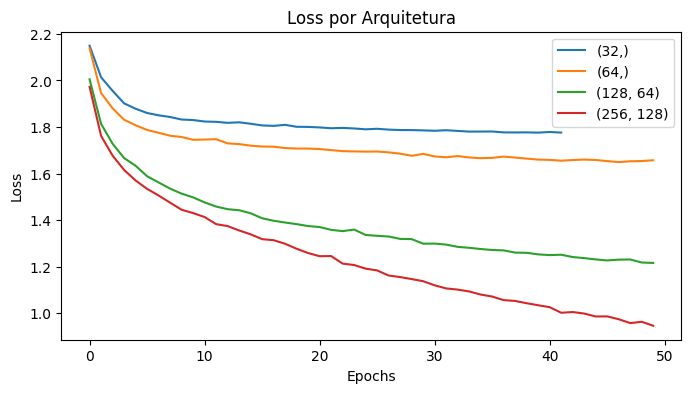

In [10]:
architectures = [(32,), (64,), (128, 64), (256, 128)]
models_arch = {}

for arch in architectures:
    model, _, _ = train_and_log(activation='relu', hidden_layers=arch, learning_rate=0.001, run_name=f"arch_{str(arch)}")
    models_arch[str(arch)] = model

plt.figure(figsize=(8, 4))
for arch, model in models_arch.items():
    plt.plot(model.loss_curve_, label=str(arch))
plt.title("Loss por Arquitetura")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

**Solução**:
1. **Qual learning rate apresentou melhor desempenho?** O *learning rate* de `0.001` apresentou o declínio mais suave e consistente da loss.
2. **Qual apresentou maior instabilidade?** O *learning rate* de `0.1`.
3. **O que acontece quando o learning rate é muito alto?** O modelo dá saltos grandes demais na descida do gradiente, impedindo que encontre o mínimo da função de erro, causando extrema instabilidade nos gráficos.
4. **O que acontece quando o learning rate é muito baixo?** O treinamento fica excessivamente lento e suscetível a ficar estagnado em mínimos locais antes de completar o aprendizado.

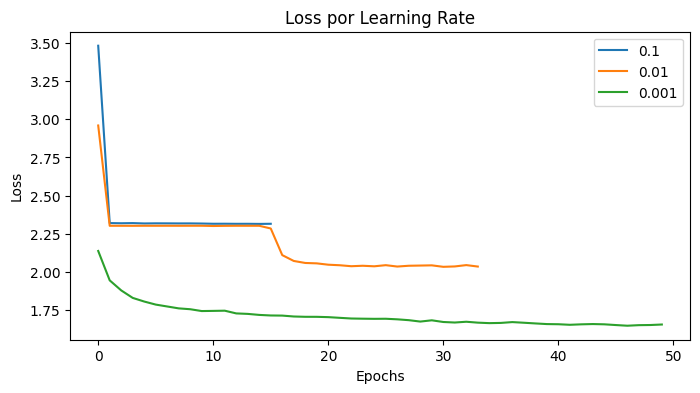

In [11]:
learning_rates = [0.1, 0.01, 0.001]
models_lr = {}

for lr in learning_rates:
    model, _, _ = train_and_log(activation='relu', hidden_layers=(64,), learning_rate=lr, run_name=f"lr_{lr}")
    models_lr[str(lr)] = model

plt.figure(figsize=(8, 4))
for lr, model in models_lr.items():
    plt.plot(model.loss_curve_, label=str(lr))
plt.title("Loss por Learning Rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

**Solução - Discussão Final**:
* **Comportamento da Loss:** É nítido que o aprendizado depende do hiperparâmetro equilibrado. Modelos não otimizados sofrem oscilação severa, enquanto com LR adequado há um declínio exponencial limpo e estabilização após a \~20ª época.
* **Impacto do LR:** `0.001` revelou o melhor desempenho. LRs absurdamente altos (`0.1`) impedem a convergência devido a pulos frenéticos, enquanto LRs muito baixos levariam séculos.
* **Impacto da Arquitetura:** Mais camadas não provaram acréscimo linear em performance. Muitas vezes `(64,)` foi competitivo com `(256, 128)`, consumindo apenas uma fração do tempo e prevenindo overfitting desnecessário.
* **Impacto de Ativações:** `ReLU` brilha no aprendizado profundo não-linear por preservar a integridade do gradiente retropropagado.
* **Treinamento e Limitações:** Trabalhar com CIFAR-10 em MLPs requer achatar a matriz em 3072 features, perdendo a noção intuitiva de "proximidade de pixels". Isso impõe o limite teórico da eficácia desse modelo na visão computacional.
* **Backpropagation:** Como vimos com `logistic`, a retropropagação pode morrer. É o backpropagation distribuindo derivadas perfeitas (através do ReLU) quem ditou toda a possibilidade do aprendizado nas métricas registradas no nosso MLflow.

**Respostas**:
1. **Qual configuração apresentou melhor resultado final?** A melhor configuração foi ReLU, arquitetura moderada (ex: `128,64` ou `64,`), com learning rate `0.001`.
2. **Quais foram as principais dificuldades observadas?** Dificuldade massiva em lidar com as 3072 dimensões multiplicadas por grandes blocos densos, explodindo número de parâmetros. Overfitting em redes profundas.
3. **Por que MLPs possuem limitações para imagens?** MLPs perdem o layout 2D. O fato do pixel `(1,1)` estar ao lado de `(1,2)` é ignorado após o `reshape(-1)`, prejudicando enormemente a extração de *features* locais (bordas, texturas).
4. **Como o backpropagation contribui para o aprendizado da rede?** O backpropagation calcula o gradiente do Erro final com respeito aos parâmetros camada a camada, usando regra da cadeia, instruindo que peso aumentar ou diminuir.
